# Bus Holding Project

### Imports + setup

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import boto3
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook', palette='deep')

### Import data

In [44]:
s3 = boto3.client('s3', region_name='us-east-1')

files = [
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-01_13:42:41.parquet',
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-02_13:42:52.parquet',
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-03_13:43:04.parquet',
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-04_13:42:58.parquet',
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-05_13:42:49.parquet',
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-08_13:42:34.parquet',
    'feeds/nyct_mta_bus_gtfsrt/COMPACTED_nyct_mta_bus_gtfsrt_2023-05-09_13:42:56.parquet',
]

import os
os.makedirs('data', exist_ok=True)

dfs = []
for f in files:
    local = f'data/{f.split("/")[-1]}'
    print(f'Downloading {local}...')
    s3.download_file('busobservatory-lake', f, local)
    dfs.append(pd.read_parquet(local))
    print('Done.')

Done.
Done.
Done.
Done.
Done.
Done.
Done.


In [45]:
df = pd.concat(dfs, ignore_index=True)
df.head()

,id,vehicle.trip.trip_id,vehicle.trip.start_date,vehicle.trip.route_id,vehicle.trip.direction_id,vehicle.position.latitude,vehicle.position.longitude,vehicle.position.bearing,vehicle.timestamp,vehicle.stop_id,vehicle.vehicle.id
0,MTA NYCT_4093,FP_B3-Sunday-054100_B7_602,20230430,B7,1.0,40.613487,-73.948479,213.996460,2023-04-30 13:40:37+00:00,307983,MTA NYCT_4093
1,MTA NYCT_5331,OH_B3-Sunday-057500_M101_42,20230430,M102,1.0,40.815331,-73.940033,233.504578,2023-04-30 13:40:18+00:00,404338,MTA NYCT_5331
2,MTA NYCT_5330,OH_B3-Sunday-052500_M15_217,20230430,M15,1.0,40.714127,-73.992790,277.666809,2023-04-30 13:40:28+00:00,404844,MTA NYCT_5330
3,MTA NYCT_7989,UP_B3-Sunday-058300_B3_109,20230430,B64,0.0,40.591167,-73.989929,146.309937,2023-04-30 13:40:41+00:00,305480,MTA NYCT_7989
4,MTA NYCT_5325,WF_B3-Sunday-056000_BX35_870,20230430,BX35,1.0,40.834538,-73.917519,157.619858,2023-04-30 13:40:27+00:00,102328,MTA NYCT_5325


In [46]:
df['vehicle.trip.route_id'].value_counts().head(20)

vehicle.trip.route_id
B6      271400
Q58     227172
B41     214530
Q44+    195138
Q27     190458
M101    177166
M4      159869
M15+    157186
BX36    153904
B35     149047
B15     143996
Q46     142282
BX9     140037
B38     139084
BX19    137970
Q25     137797
Q65     136750
B46     135671
M3      133269
B103    133094
Name: count, dtype: int64

### Clean and filter data


In [47]:
m15 = df[df['vehicle.trip.route_id'] == 'M15'].copy() # bus route we're modelling
m15 = m15[m15['vehicle.trip.direction_id'] == 1.0].copy() # make sure they're all going in the same direction (higher traffic)
m15['time'] = pd.to_datetime(m15['vehicle.timestamp'], unit='s')

m15

,id,vehicle.trip.trip_id,vehicle.trip.start_date,vehicle.trip.route_id,vehicle.trip.direction_id,vehicle.position.latitude,vehicle.position.longitude,vehicle.position.bearing,vehicle.timestamp,vehicle.stop_id,vehicle.vehicle.id,time
2,MTA NYCT_5330,OH_B3-Sunday-052500_M15_217,20230430,M15,1.0,40.714127,-73.992790,277.666809,2023-04-30 13:40:28+00:00,404844,MTA NYCT_5330,2023-04-30 13:40:28+00:00
642,MTA NYCT_5921,OH_B3-Sunday-051200_M15_218,20230430,M15,1.0,40.710335,-73.991867,99.854454,2023-04-30 13:40:31+00:00,405359,MTA NYCT_5921,2023-04-30 13:40:31+00:00
645,MTA NYCT_5915,OH_B3-Sunday-056100_M15_219,20230430,M15,1.0,40.773228,-73.955132,234.648788,2023-04-30 13:40:26+00:00,401756,MTA NYCT_5915,2023-04-30 13:40:26+00:00
646,MTA NYCT_5919,OH_B3-Sunday-057300_M15_205,20230430,M15,1.0,40.793713,-73.940178,234.436996,2023-04-30 13:40:32+00:00,803228,MTA NYCT_5919,2023-04-30 13:40:32+00:00
911,MTA NYCT_6067,OH_B3-Sunday-054900_M15_212,20230430,M15,1.0,40.761013,-73.964050,233.130096,2023-04-30 13:40:27+00:00,401765,MTA NYCT_6067,2023-04-30 13:40:27+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
18636881,MTA NYCT_5891,OH_B3-Weekday-SDon-052300_M15_229,20230509,M15,1.0,40.786907,-73.945152,233.882568,2023-05-09 13:03:17+00:00,401748,MTA NYCT_5891,2023-05-09 13:03:17+00:00
18636884,MTA NYCT_5896,OH_B3-Weekday-SDon-045900_M15_210,20230509,M15,1.0,40.714405,-73.992828,278.972626,2023-05-09 13:03:22+00:00,404844,MTA NYCT_5896,2023-05-09 13:03:22+00:00
18637819,MTA NYCT_5927,OH_B3-Weekday-SDon-053900_M15_212,20230509,M15,1.0,40.796509,-73.938118,233.880661,2023-05-09 13:03:27+00:00,401742,MTA NYCT_5927,2023-05-09 13:03:27+00:00
18637823,MTA NYCT_5910,OH_B3-Weekday-SDon-046700_M15_223,20230509,M15,1.0,40.723312,-73.990173,343.361206,2023-05-09 13:03:29+00:00,403849,MTA NYCT_5910,2023-05-09 13:03:29+00:00


In [48]:
# Filter to peak weekday hours
m15['hour'] = m15['time'].dt.hour
m15['weekday'] = m15['time'].dt.weekday
m15 = m15[
    (m15['weekday'] < 5) &
    ((m15['hour'].between(7, 9)) | (m15['hour'].between(16, 19)))
].copy()

m15

,id,vehicle.trip.trip_id,vehicle.trip.start_date,vehicle.trip.route_id,vehicle.trip.direction_id,vehicle.position.latitude,vehicle.position.longitude,vehicle.position.bearing,vehicle.timestamp,vehicle.stop_id,vehicle.vehicle.id,time,hour,weekday
1309225,MTA NYCT_5870,OH_B3-Weekday-SDon-015000_M15_202,20230501,M15,1.0,40.724075,-73.990952,234.688782,2023-05-01 07:00:50+00:00,401787,MTA NYCT_5870,2023-05-01 07:00:50+00:00,7,0
1309433,MTA NYCT_5870,OH_B3-Weekday-SDon-015000_M15_202,20230501,M15,1.0,40.723244,-73.989944,343.361206,2023-05-01 07:01:21+00:00,403849,MTA NYCT_5870,2023-05-01 07:01:21+00:00,7,0
1309643,MTA NYCT_5870,OH_B3-Weekday-SDon-015000_M15_202,20230501,M15,1.0,40.722301,-73.989006,248.234344,2023-05-01 07:02:21+00:00,403647,MTA NYCT_5870,2023-05-01 07:02:21+00:00,7,0
1309859,MTA NYCT_5870,OH_B3-Weekday-SDon-015000_M15_202,20230501,M15,1.0,40.718910,-73.990662,242.612579,2023-05-01 07:03:22+00:00,405373,MTA NYCT_5870,2023-05-01 07:03:22+00:00,7,0
1310074,MTA NYCT_5870,OH_B3-Weekday-SDon-015000_M15_202,20230501,M15,1.0,40.716454,-73.991920,243.067535,2023-05-01 07:04:23+00:00,405373,MTA NYCT_5870,2023-05-01 07:04:23+00:00,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17954841,MTA NYCT_5927,OH_B3-Weekday-SDon-035800_M15_212,20230509,M15,1.0,40.801357,-73.934578,233.864624,2023-05-09 09:59:30+00:00,401739,MTA NYCT_5927,2023-05-09 09:59:30+00:00,9,1
18259589,MTA NYCT_5867,OH_B3-Weekday-SDon-023000_M15_205,20230509,M15,1.0,40.798374,-73.936745,233.287582,2023-05-09 07:53:35+00:00,401741,MTA NYCT_5867,2023-05-09 07:53:35+00:00,7,1
18259653,MTA NYCT_5926,OH_B3-Weekday-SDon-021000_M15_204,20230509,M15,1.0,40.746201,-73.974854,233.758224,2023-05-09 07:53:15+00:00,404909,MTA NYCT_5926,2023-05-09 07:53:15+00:00,7,1
18259818,MTA NYCT_5867,OH_B3-Weekday-SDon-023000_M15_205,20230509,M15,1.0,40.795811,-73.938629,233.130096,2023-05-09 07:54:37+00:00,401742,MTA NYCT_5867,2023-05-09 07:54:37+00:00,7,1


Compute the distance gaps between consecutive buses. At each 1-minute snapshot we sort active buses by latitude and emit one row per consecutive `(leader, follower)` pair, tagged by both vehicle IDs. This lets us reconstruct per-pair gap trajectories — actual sample paths of the OU process from §2.1 — rather than a fleet-level spatial average. Each observation is now the kind of quantity a dispatcher would observe and act on, and matches the state variable of the controller in §3.

In [49]:
m15 = m15.sort_values(['time', 'vehicle.position.latitude'], ascending=[True, False])
m15['minute'] = m15['time'].dt.floor('1min')  # 1-min time buckets for grouping snapshots

# At each 1-min snapshot, sort active M15 northbound buses N->S and emit one row per
# consecutive (leader, follower) pair, tagged by both vehicle IDs. This preserves
# pair identity so we can later string together each pair's gap trajectory.
records = []
for minute, group in m15.groupby('minute'):
    g = (group.drop_duplicates('vehicle.vehicle.id')
              .sort_values('vehicle.position.latitude', ascending=False))
    if len(g) < 2:
        continue
    vids = g['vehicle.vehicle.id'].values
    lats = g['vehicle.position.latitude'].values
    for i in range(len(vids) - 1):
        records.append({
            'minute':   minute,
            'leader':   vids[i],          # bus to the north
            'follower': vids[i + 1],      # bus to the south
            'gap_km':   (lats[i] - lats[i + 1]) * 111  # lat-degree -> km
        })

pairs_df = pd.DataFrame(records)
pairs_df.head(10)

,minute,leader,follower,gap_km
0,2023-05-01 07:06:00+00:00,MTA NYCT_5834,MTA NYCT_5870,9.079216
1,2023-05-01 07:07:00+00:00,MTA NYCT_5834,MTA NYCT_5870,8.506737
2,2023-05-01 07:08:00+00:00,MTA NYCT_5834,MTA NYCT_5870,8.032917
3,2023-05-01 07:09:00+00:00,MTA NYCT_5834,MTA NYCT_5870,8.006241
4,2023-05-01 07:10:00+00:00,MTA NYCT_5834,MTA NYCT_5870,7.961781
5,2023-05-01 07:11:00+00:00,MTA NYCT_5834,MTA NYCT_5870,7.681892
6,2023-05-01 07:12:00+00:00,MTA NYCT_5834,MTA NYCT_5870,7.280903
7,2023-05-01 07:13:00+00:00,MTA NYCT_5834,MTA NYCT_5870,7.243641
8,2023-05-01 07:14:00+00:00,MTA NYCT_5834,MTA NYCT_5870,7.108566
9,2023-05-01 07:15:00+00:00,MTA NYCT_5834,MTA NYCT_5870,6.664810


Build $(G_t, G_{t+1})$ regression pairs from per-pair trajectories. We only keep observations where the *same* `(leader, follower)` pair was consecutive at both minute $t$ and minute $t+1$ — so each regression pair represents one bus following another bus from one minute to the next, never spanning a "pair break" (where a third bus enters between them, or one bus ends its trip). This pools across all pair-trajectories present in the filtered dataset, treating each pair as an i.i.d. sample of the same OU process under the stationarity-during-peak-hours assumption.

In [50]:
# Sort by pair, then by minute. Within each (leader, follower) group, shift the
# next minute and next gap forward; a regression pair (G_t, G_{t+1}) is valid
# iff the next observation in the same pair group is exactly 1 minute later.
pairs_df = pairs_df.sort_values(['leader', 'follower', 'minute']).reset_index(drop=True)
pairs_df['next_minute'] = pairs_df.groupby(['leader', 'follower'])['minute'].shift(-1)
pairs_df['next_gap']    = pairs_df.groupby(['leader', 'follower'])['gap_km'].shift(-1)

# Adjacent-minute pairs only; drop physically implausible gaps (overlap / route-edge artifacts)
mask  = (pairs_df['next_minute'] - pairs_df['minute']) == pd.Timedelta('1min')
mask &= pairs_df['gap_km'].between(0.05, 4.0)
mask &= pairs_df['next_gap'].between(0.05, 4.0)

ar1_pairs = pairs_df.loc[mask, ['minute', 'leader', 'follower', 'gap_km', 'next_gap']]

print(f"Total pair-minute rows:                 {len(pairs_df)}")
print(f"Distinct (leader, follower) pairs:      {pairs_df.groupby(['leader','follower']).ngroups}")
print(f"AR(1) regression pairs (G_t, G_{{t+1}}):  {len(ar1_pairs)}")
print()
print(ar1_pairs['gap_km'].describe())

Total pair-minute rows:                 13062
Distinct (leader, follower) pairs:      446
AR(1) regression pairs (G_t, G_{t+1}):  10076

count    10076.000000
mean         1.361185
std          0.886808
min          0.050388
25%          0.664258
50%          1.205509
75%          1.952442
max          3.993805
Name: gap_km, dtype: float64


Fit AR(1) regression to confirm autocorrelation

In [61]:
# Fit AR(1) on the pooled (G_t, G_{t+1}) pairs from per-pair trajectories.
G_t  = ar1_pairs['gap_km'].values
G_t1 = ar1_pairs['next_gap'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(G_t, G_t1)
print(f"AR(1) fit (per-pair, 1-min sampling):")
print(f"  beta  = {slope:.4f}")
print(f"  R²    = {r_value**2:.4f}")
print(f"  alpha = {intercept:.4f}")
print(f"  s     = {(G_t1 - (intercept + slope * G_t)).std():.4f}")
print(f"  p     = {p_value:.4e}")
print(f"  n     = {len(G_t)}")

AR(1) fit (per-pair, 1-min sampling):
  beta  = 0.9820
  R²    = 0.9789
  alpha = 0.0170
  s     = 0.1278
  p     = 0.0000e+00
  n     = 10076


A high $\beta$ (close to 1) indicates strong autocorrelation — each per-pair gap behaves as a slowly mean-reverting process, consistent with the OU model. The $R^2$ tells us how much variance the AR(1) discretization captures; the residual variance is what feeds the diffusion coefficient $\sigma$.

### Plot and Verify Mean-Reversion Assumption

In [52]:
residuals = G_t1 - (intercept + slope * G_t)
s = residuals.std()

dt = 1.0  # 1-minute sampling interval (per-pair, adjacent minutes)
kappa = -np.log(max(slope, 1e-10)) / dt
G_bar = intercept / (1 - slope)
sigma = s * np.sqrt(2 * kappa / (1 - slope**2))

print(f"OU Parameters (per-pair, 1-min):")
print(f"  kappa = {kappa:.4f} per minute")
print(f"  G_bar = {G_bar:.4f} km")
print(f"  sigma = {sigma:.4f} km/√min")

OU Parameters (per-pair, 1-min):
  kappa = 0.0182 per minute
  G_bar = 0.9414 km
  sigma = 0.1289 km/√min


#### Fitted Params

$\kappa$: mean-reversion speed (per minute). The half-life of a gap deviation is $\ln(2)/\kappa$ minutes — how fast a perturbed gap returns to equilibrium.

$\bar{G}$ (km): the equilibrium per-pair spacing. Inter-bus gaps between a fixed leader–follower pair are pulled toward this during peak hours.

$\sigma$ (km/√min): the per-pair noise scale. Traffic, signal timing, boarding randomness — everything we can't predict that pushes the leader–follower gap around between minute ticks.

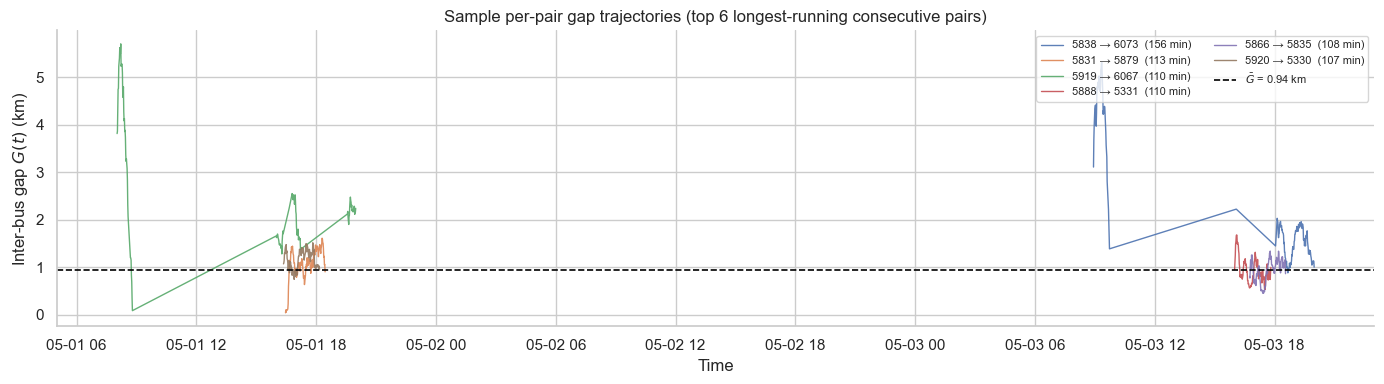

In [53]:
# Plot the longest-running per-pair trajectories. Each line is one (leader, follower)
# pair's gap G(t) in km, sampled every minute they remained consecutive.
pair_lengths = (pairs_df.groupby(['leader', 'follower']).size()
                        .sort_values(ascending=False))
top_pairs = pair_lengths.head(6).index.tolist()

fig, ax = plt.subplots(figsize=(14, 4))
palette = sns.color_palette('deep', n_colors=len(top_pairs))
for (leader, follower), color in zip(top_pairs, palette):
    traj = (pairs_df[(pairs_df['leader'] == leader) &
                     (pairs_df['follower'] == follower)]
            .set_index('minute')['gap_km'].sort_index())
    ax.plot(traj.index, traj.values, linewidth=1.0, color=color, alpha=0.9,
            label=f'{leader[-4:]} → {follower[-4:]}  ({len(traj)} min)')

ax.axhline(G_bar, linestyle='--', color='black', linewidth=1.2,
           label=f'$\\bar{{G}}$ = {G_bar:.2f} km')
ax.set_xlabel('Time')
ax.set_ylabel('Inter-bus gap $G(t)$ (km)')
ax.set_title('Sample per-pair gap trajectories (top 6 longest-running consecutive pairs)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

### HJB Solver

In [54]:
dt_solver = 0.005  # small enough for advection + diffusion stability

# Cost weights
alpha = 1.0 # bunching penalty
beta = 0.01 # holding penalty
tau_max = 0.5 # max holding rate (km/min)

dG = 0.1 # spatial step

# Grid
G_grid = np.arange(0.0, 6.0 + dG, dG)
N_G = len(G_grid)

# Time Horizon
T = 120 # two hour peak period
t_grid = np.arange(0, T + dt_solver, dt_solver)
N_t = len(t_grid)

Check the CFL (Courant-Friedrichs-Lewy) to verify stability condition. For advection-diffusion PDEs, both terms must be stable:

**Diffusion:** $\frac{\sigma^2 \Delta t}{\Delta G^2} \leq \frac{1}{2}$

**Advection:** $\frac{|\mu_{\max}| \Delta t}{\Delta G} \leq 1$

where $\mu_{\max} = \kappa \cdot G_{\max} + \tau_{\max}$ is the worst-case drift.

In [55]:
cfl_diff = sigma**2 * dt_solver / dG**2
mu_max = kappa * G_grid.max() + tau_max
cfl_adv = mu_max * dt_solver / dG

print(f"Diffusion CFL:  {cfl_diff:.4f} — {'STABLE' if cfl_diff <= 0.5 else 'UNSTABLE'}")
print(f"Advection CFL:  {cfl_adv:.4f} — {'STABLE' if cfl_adv <= 1.0 else 'UNSTABLE'}")

Diffusion CFL:  0.0083 — STABLE
Advection CFL:  0.0305 — STABLE


#### Initialize value function
Terminal condition: $V(G, T) = 0 \forall G$ - no cost remaining at end of horizon

$V(G, t)$ represents the minimum expected cost from now until $T$ given you're currently at gap G at time t.

In [56]:
V = np.zeros((N_G, N_t))
tau_star = np.zeros((N_G, N_t))

#### Backward Sweep
Solve HJB backwards from $t = T$ to $t = 0$
At each step: approximate spatial derivatives via finite differences, solve bang-bang condition for $\tau^*$, update $V^k$ explicitly

In [57]:
# Solver

for k in range(N_t - 2, -1, -1):
    V_k1 = V[:, k + 1]
    
    # First derivative (central differences interior, 3-point at boundaries)
    dV = np.zeros(N_G)
    dV[1:-1] = (V_k1[2:] - V_k1[:-2]) / (2 * dG)
    dV[0] = (-3 * V_k1[0] + 4 * V_k1[1] - V_k1[2]) / (2 * dG)
    dV[-1] = (3 * V_k1[-1] - 4 * V_k1[-2] + V_k1[-3]) / (2 * dG)

    # Second derivative (midpoint formula)
    d2V = np.zeros(N_G)
    d2V[1:-1] = (V_k1[2:] - 2 * V_k1[1:-1] + V_k1[:-2]) / dG**2
    d2V[0] = d2V[1]
    d2V[-1] = d2V[-2]

    # Bang-bang optimal policy: minimize tau*(beta - dV)
    # hold (tau_max) when dV > beta, i.e. cost increases with gap
    tau = np.where(dV >= beta, tau_max, 0.0)
    tau_star[:, k] = tau

    # Explicit backward update
    V[:, k] = V_k1 + dt_solver * (
        alpha * (G_bar - G_grid)**2 
        + beta * tau + (kappa * 
        (G_bar - G_grid) - tau) 
        * dV + 0.5 * sigma**2 * d2V
    )

print("Solver complete.")
print(f"V range:    [{V.min():.2f}, {V.max():.2f}]")
print(f"tau* range: [{tau_star.min():.2f}, {tau_star.max():.2f}]")

Solver complete.
V range:    [0.00, 99.42]
tau* range: [0.00, 0.50]


#### Plot value function and optimal policy

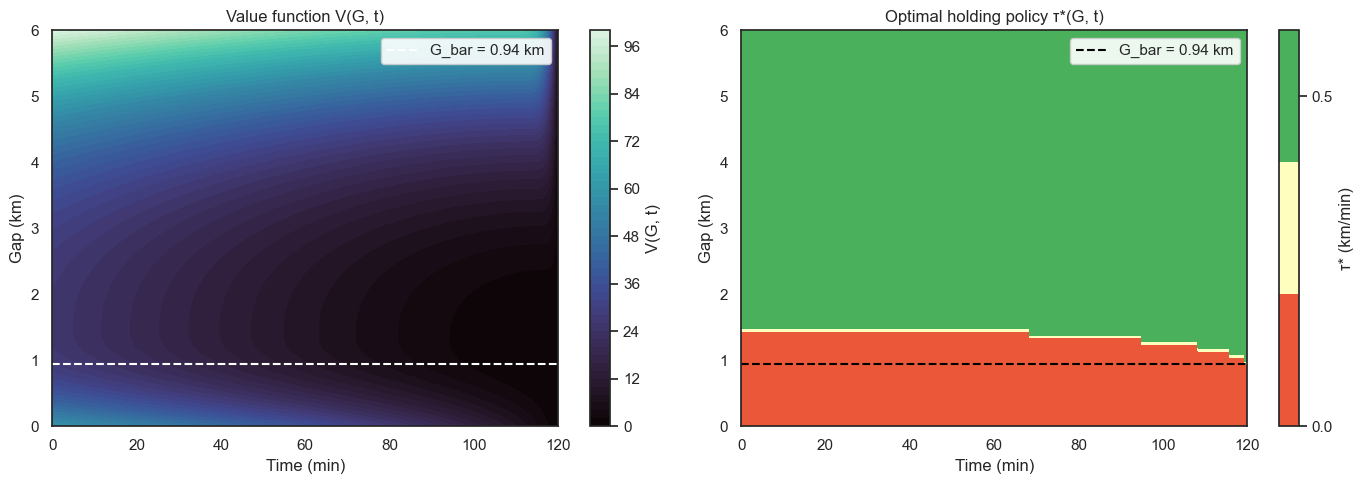

In [62]:
with sns.axes_style('white'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im1 = axes[0].contourf(t_grid, G_grid, V, levels=50, cmap='mako')
    cbar1 = plt.colorbar(im1, ax=axes[0])
    cbar1.set_label('V(G, t)')
    axes[0].axhline(G_bar, color='white', linestyle='--', linewidth=1.5,
                    label=f'G_bar = {G_bar:.2f} km')
    axes[0].set_xlabel('Time (min)')
    axes[0].set_ylabel('Gap (km)')
    axes[0].set_title('Value function V(G, t)')
    axes[0].legend(loc='upper right', framealpha=0.9)

    im2 = axes[1].contourf(t_grid, G_grid, tau_star, levels=2, cmap='RdYlGn')
    cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[0, tau_max])
    cbar2.set_label('τ* (km/min)')
    axes[1].axhline(G_bar, color='black', linestyle='--', linewidth=1.5,
                    label=f'G_bar = {G_bar:.2f} km')
    axes[1].set_xlabel('Time (min)')
    axes[1].set_ylabel('Gap (km)')
    axes[1].set_title('Optimal holding policy τ*(G, t)')
    axes[1].legend(loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.savefig('hjb_solution.png', dpi=150, bbox_inches='tight')
    plt.show()

### Monte Carlo Simulation
Simulate 1000 OU paths forward in time. At each step, we apply the optimal policy by looking up $\tau^*(G, t)$ from the precomputed grid. Compare total cost against a no-holding baseline. 

In [59]:
np.random.seed(42)
N_paths = 1000
G0 = G_bar  # start at equilibrium

costs_opt      = np.zeros(N_paths)
costs_baseline = np.zeros(N_paths)

for n in range(N_paths):
    G_opt  = G0
    G_base = G0
    cost_opt  = 0.0
    cost_base = 0.0

    for k in range(N_t - 1):
        Z = np.random.randn()

        # Look up optimal tau from precomputed grid
        i = np.argmin(np.abs(G_grid - G_opt))
        tau = tau_star[i, k]

        # Accumulate costs
        cost_opt  += dt_solver * (alpha * (G_bar - G_opt)**2  + beta * tau)
        cost_base += dt_solver * (alpha * (G_bar - G_base)**2)

        # Evolve both paths with same random shock
        G_opt  = G_opt  + (kappa*(G_bar - G_opt)  - tau)*dt_solver + sigma*np.sqrt(dt_solver)*Z
        G_base = G_base +  kappa*(G_bar - G_base)       *dt_solver + sigma*np.sqrt(dt_solver)*Z

        # Keep in bounds
        G_opt  = np.clip(G_opt,  G_grid[0], G_grid[-1])
        G_base = np.clip(G_base, G_grid[0], G_grid[-1])

    costs_opt[n]      = cost_opt
    costs_baseline[n] = cost_base

print(f"Mean cost — optimal policy:  {costs_opt.mean():.4f}")
print(f"Mean cost — no holding:      {costs_baseline.mean():.4f}")
print(f"Cost reduction:              {(1 - costs_opt.mean()/costs_baseline.mean())*100:.1f}%")

Mean cost — optimal policy:  17.4817
Mean cost — no holding:      32.1523
Cost reduction:              45.6%


### Cost Distribution

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

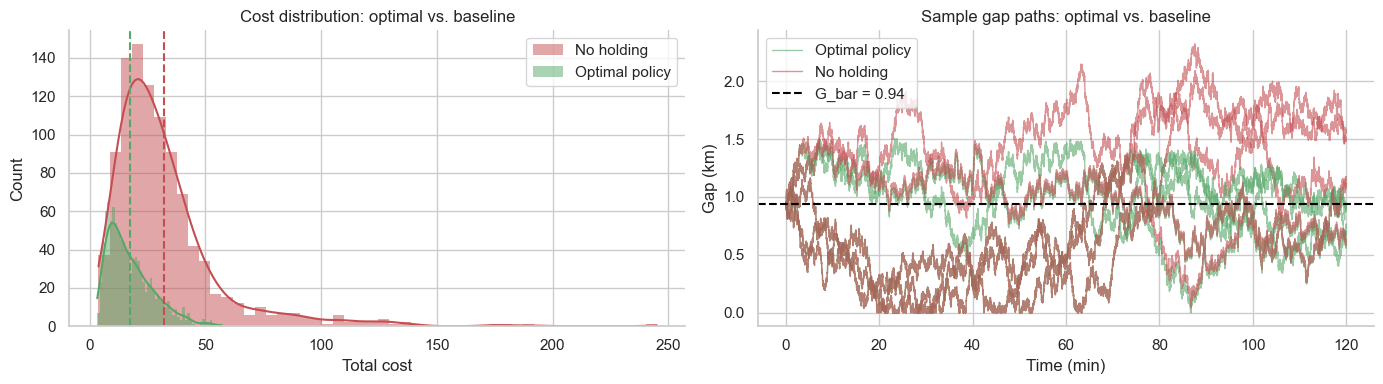

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

palette = sns.color_palette('deep')
baseline_color = palette[3]   # red
optimal_color = palette[2]    # green

# Cost distribution — KDE-overlaid histograms
sns.histplot(costs_baseline, bins=50, ax=axes[0], color=baseline_color,
             alpha=0.5, kde=True, label='No holding', stat='count',
             edgecolor='none')
sns.histplot(costs_opt, bins=50, ax=axes[0], color=optimal_color,
             alpha=0.5, kde=True, label='Optimal policy', stat='count',
             edgecolor='none')
axes[0].axvline(costs_baseline.mean(), color=baseline_color, linestyle='--', linewidth=1.5)
axes[0].axvline(costs_opt.mean(), color=optimal_color, linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Total cost')
axes[0].set_ylabel('Count')
axes[0].set_title('Cost distribution: optimal vs. baseline')
axes[0].legend()

# Sample paths
axes[1].set_title('Sample gap paths: optimal vs. baseline')
opt_label_used = base_label_used = False
for n in range(5):
    np.random.seed(n)
    G_opt  = G0
    G_base = G0
    path_opt  = [G_opt]
    path_base = [G_base]
    for k in range(N_t - 1):
        Z = np.random.randn()
        i = np.argmin(np.abs(G_grid - G_opt))
        tau = tau_star[i, k]
        G_opt  = np.clip(G_opt  + (kappa*(G_bar-G_opt) -tau)*dt_solver + sigma*np.sqrt(dt_solver)*Z, G_grid[0], G_grid[-1])
        G_base = np.clip(G_base +  kappa*(G_bar-G_base)    *dt_solver + sigma*np.sqrt(dt_solver)*Z, G_grid[0], G_grid[-1])
        path_opt.append(G_opt)
        path_base.append(G_base)
    sns.lineplot(x=t_grid, y=path_opt, ax=axes[1], color=optimal_color,
                 alpha=0.6, linewidth=1.0,
                 label='Optimal policy' if not opt_label_used else None)
    sns.lineplot(x=t_grid, y=path_base, ax=axes[1], color=baseline_color,
                 alpha=0.6, linewidth=1.0,
                 label='No holding' if not base_label_used else None)
    opt_label_used = base_label_used = True

axes[1].axhline(G_bar, color='black', linestyle='--', linewidth=1.5,
                label=f'G_bar = {G_bar:.2f}')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('Gap (km)')
axes[1].legend()

sns.despine(fig=fig)
plt.tight_layout()
plt.show()